# AAPL Stock Price Prediction — Part 2: EDA

Exploratory data analysis of AAPL daily prices and technical indicators. The key result of this notebook is the **autocorrelation analysis of daily returns**, which reveals that the return series is essentially white noise — a first indication that short-term prediction from technical indicators alone is very difficult.

**Input:** `AAPL.csv` (produced by notebook 01)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.stattools import durbin_watson

sns.set_style("whitegrid")

data = pd.read_csv("AAPL.csv", parse_dates=["Date"], index_col="Date")
returns = data["Close"].pct_change().dropna()

print(f"Data: {data.index[0].date()} – {data.index[-1].date()}  |  {len(data)} trading days")
print(f"\nReturns summary:")
print(returns.describe().round(4))

Data: 1980-12-12 – 2026-03-06  |  11399 trading days

Returns summary:
count    11398.0000
mean         0.0011
std          0.0276
min         -0.5187
25%         -0.0124
50%          0.0000
75%          0.0142
max          0.3323
Name: Close, dtype: float64


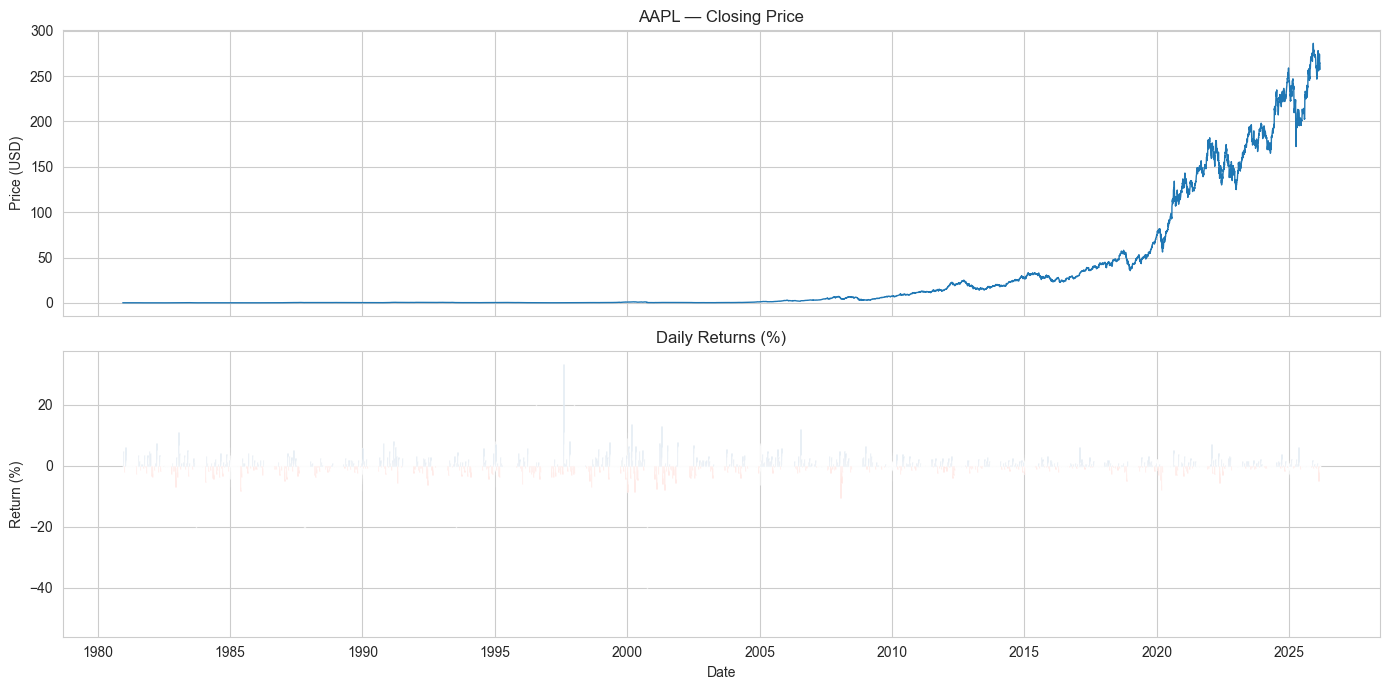

In [2]:
# ---------------------------------------------------------------
# Price history
# ---------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(data["Close"], linewidth=1)
axes[0].set_title("AAPL — Closing Price")
axes[0].set_ylabel("Price (USD)")

axes[1].bar(data.index, data["Close"].pct_change() * 100, width=1,
            color=np.where(data["Close"].pct_change() >= 0, "steelblue", "tomato"), alpha=0.6)
axes[1].set_title("Daily Returns (%)")
axes[1].set_ylabel("Return (%)")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.savefig("plot1_price_returns.png", dpi=150)
plt.show()

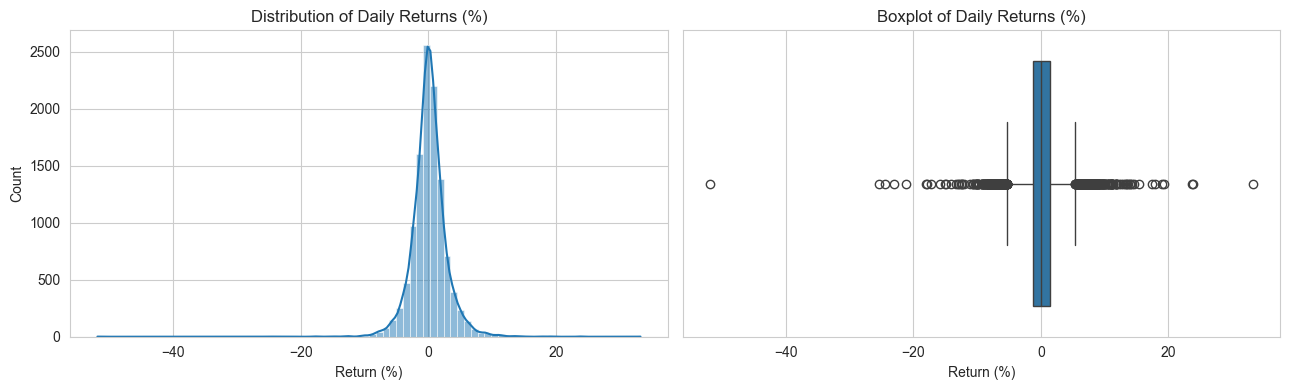

Skewness:  -0.360
Kurtosis:  18.651  (normal = 0)


In [3]:
# ---------------------------------------------------------------
# Distribution of daily returns
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(returns * 100, bins=80, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Daily Returns (%)")
axes[0].set_xlabel("Return (%)")

sns.boxplot(x=returns * 100, ax=axes[1])
axes[1].set_title("Boxplot of Daily Returns (%)")
axes[1].set_xlabel("Return (%)")

plt.tight_layout()
plt.savefig("plot2_return_distribution.png", dpi=150)
plt.show()

# Kurtosis — fat tails are typical for equity returns
print(f"Skewness:  {returns.skew():.3f}")
print(f"Kurtosis:  {returns.kurtosis():.3f}  (normal = 0)")

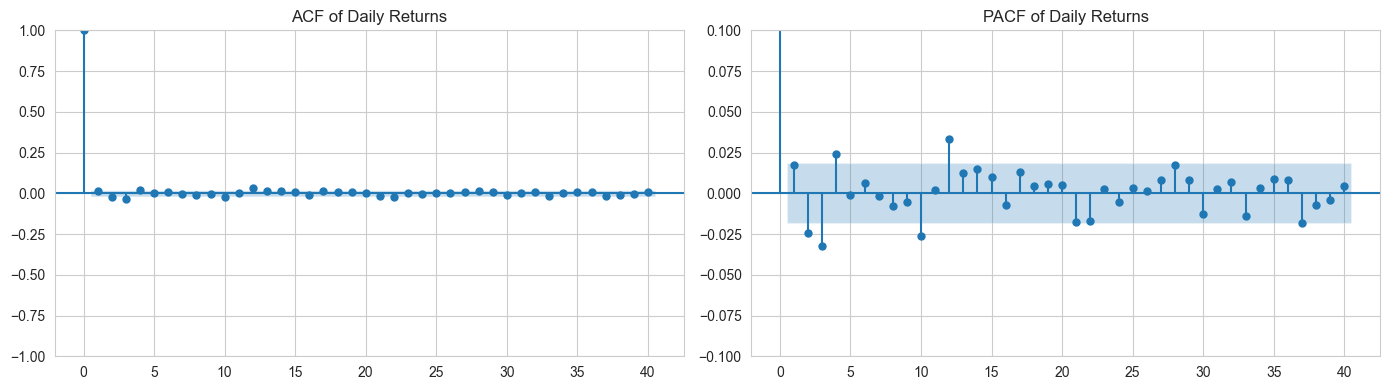

Durbin-Watson statistic: 1.962  (2.0 = no autocorrelation)

Interpretation:
  All lags are within the 95% confidence band -> returns are uncorrelated white noise.
  This is consistent with the Efficient Market Hypothesis (EMH, weak form).
  Technical indicators, being derived from past prices, carry no additional information.


In [12]:
# ---------------------------------------------------------------
# Autocorrelation of returns — the key diagnostic
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(returns,  ax=axes[0], lags=40, title="ACF of Daily Returns")
plt.ylim(-0.1,0.1)
plot_pacf(returns, ax=axes[1], lags=40, title="PACF of Daily Returns")
plt.ylim(-0.1,0.1)
plt.tight_layout()
plt.savefig("plot3_acf_pacf.png", dpi=150)
plt.show()
#

dw = durbin_watson(returns.values)
print(f"Durbin-Watson statistic: {dw:.3f}  (2.0 = no autocorrelation)")
print()
print("Interpretation:")
print("  All lags are within the 95% confidence band -> returns are uncorrelated white noise.")
print("  This is consistent with the Efficient Market Hypothesis (EMH, weak form).")
print("  Technical indicators, being derived from past prices, carry no additional information.")

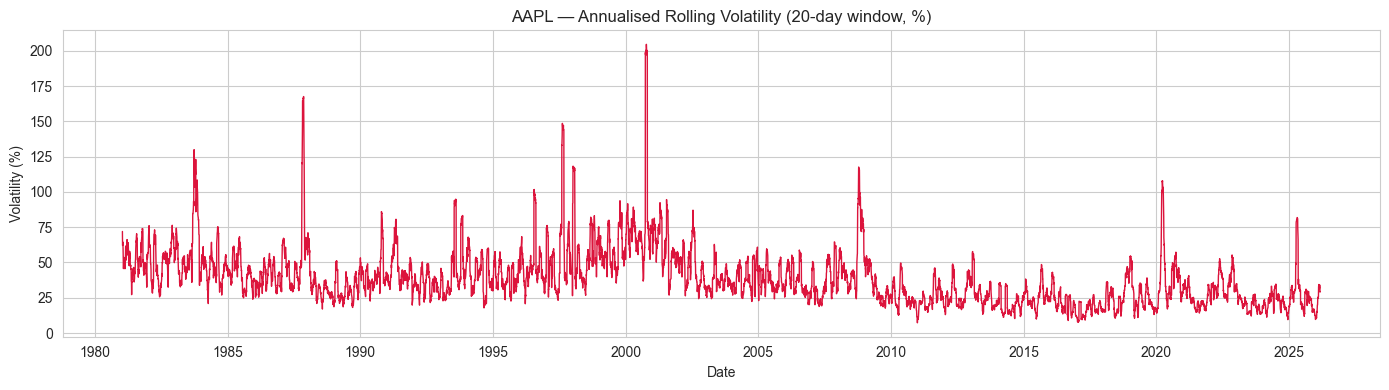

Volatility is time-varying (ARCH effect) — predictable in magnitude but not in direction.


In [5]:
# ---------------------------------------------------------------
# Rolling volatility — volatility clustering
# ---------------------------------------------------------------
rolling_vol = returns.rolling(20).std() * np.sqrt(252) * 100  # annualised %

plt.figure(figsize=(14, 4))
plt.plot(rolling_vol, color="crimson", linewidth=1)
plt.title("AAPL — Annualised Rolling Volatility (20-day window, %)")
plt.ylabel("Volatility (%)")
plt.xlabel("Date")
plt.tight_layout()
plt.savefig("plot4_volatility.png", dpi=150)
plt.show()

print("Volatility is time-varying (ARCH effect) — predictable in magnitude but not in direction.")

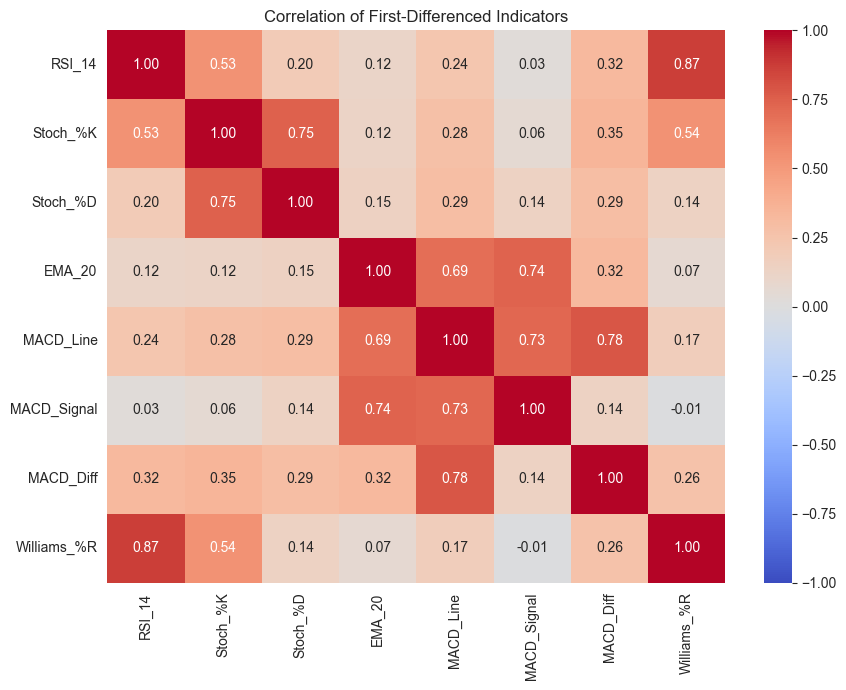


EDA Summary
  Total trading days:      11399
  Mean daily return:       0.105%
  Std daily return:        2.761%
  Max daily return:        33.23%
  Min daily return:        -51.87%
  Durbin-Watson:           1.962
  Autocorrelation (lag 1): 0.0174

  -> Daily returns are statistically indistinguishable from white noise.
  -> No meaningful signal in past returns for next-day prediction.


In [6]:
# ---------------------------------------------------------------
# Correlation heatmap of features
# ---------------------------------------------------------------
indicator_cols = ["RSI_14", "Stoch_%K", "Stoch_%D", "EMA_20",
                  "MACD_Line", "MACD_Signal", "MACD_Diff", "Williams_%R"]

# Use returns-based features to avoid spurious correlation from trending prices
feat_returns = data[indicator_cols].diff().dropna()

plt.figure(figsize=(9, 7))
sns.heatmap(feat_returns.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation of First-Differenced Indicators")
plt.tight_layout()
plt.savefig("plot5_correlation.png", dpi=150)
plt.show()

print("\nEDA Summary")
print("=" * 50)
print(f"  Total trading days:      {len(data)}")
print(f"  Mean daily return:       {returns.mean()*100:.3f}%")
print(f"  Std daily return:        {returns.std()*100:.3f}%")
print(f"  Max daily return:        {returns.max()*100:.2f}%")
print(f"  Min daily return:        {returns.min()*100:.2f}%")
print(f"  Durbin-Watson:           {durbin_watson(returns.values):.3f}")
print(f"  Autocorrelation (lag 1): {returns.autocorr(1):.4f}")
print()
print("  -> Daily returns are statistically indistinguishable from white noise.")
print("  -> No meaningful signal in past returns for next-day prediction.")